# Proyecto SVM para Detección de Spam en URLs
El objetivo es detectar si una URL es spam o no, basado en su contenido, utilizando un modelo SVM.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import warnings
warnings.simplefilter('ignore')
import joblib

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# CARGA DE DATOS
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"
df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2999, 2)


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [5]:
# VERIFICACIÓN DE NULOS Y DUPLICADOS
print("Valores nulos por columna:")
print(df.isnull().sum().sum())

print(f"Filas duplicadas: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Dimensiones tras eliminar duplicados: {df.shape}")

Valores nulos por columna:
0
Filas duplicadas: 630
Dimensiones tras eliminar duplicados: (2369, 2)


In [6]:
# DISTRIBUCIÓN DE CLASES
print("Distribución de clases:")
print(df['is_spam'].value_counts(normalize=True) * 100)

Distribución de clases:
is_spam
False    89.700295
True     10.299705
Name: proportion, dtype: float64


# Preprocesamiento de URLs
Dividimos las URLs en tokens usando delimitadores comunes. Convertimos a minúsculas, eliminamos stopwords y lematizamos. Tambien eliminamos palabras que se repiten en todas las url y no aportan información.

In [37]:
# PREPROCESAMIENTO
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

url_junk = ['http', 'https', 'www', 'com', 'org', 'net', 'html', 'php', 'aspx']
stop_words.update(url_junk)

def preprocess_url(url):
    # Segmentar por delimitadores
    tokens = re.split(r'[/\?=&\.-_]', url.lower())
    # Filtrar tokens vacíos, cortos, stopwords y lematizar
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token and len(token) > 2 and token not in stop_words]
    return ' '.join(tokens)

df['url_clean'] = df['url'].apply(preprocess_url)
df[['url', 'url_clean']].head()

,url,url_clean
0,https://briefingday.us8.list-manage.com/unsubs...,briefingday list-manage unsubscribe
1,https://www.hvper.com/,hvper
2,https://briefingday.com/m/v4n3i4f3,briefingday
3,https://briefingday.com/n/20200618/m#commentform,briefingday m#commentform
4,https://briefingday.com/fan,briefingday fan


Convertimos is_spam a numérico (True=1, False=0).

In [38]:
df['is_spam'] = df['is_spam'].astype(int)

In [39]:
# DIVISION TRAIN / TEST
X = df['url_clean']
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño train: (1895,)
Tamaño test: (474,)


In [40]:
# MODELO BASE
pipeline_base = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('svm', SVC(kernel='linear', random_state=42))
])

pipeline_base.fit(X_train, y_train)

y_pred_base = pipeline_base.predict(X_test)

print(classification_report(y_test, y_pred_base))
print("AUC:", roc_auc_score(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       425
           1       0.88      0.45      0.59        49

    accuracy                           0.94       474
   macro avg       0.91      0.72      0.78       474
weighted avg       0.93      0.94      0.93       474

AUC: 0.7209603841536615


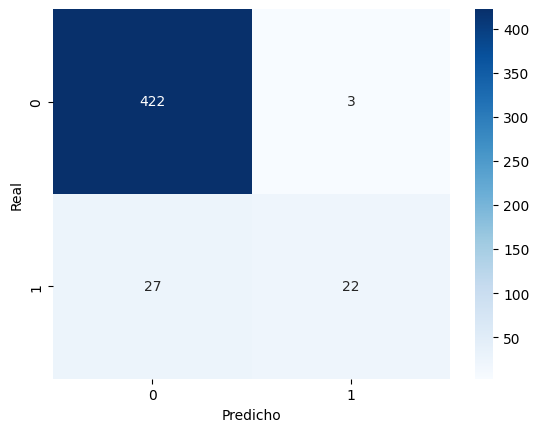

In [41]:
# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


In [42]:
# OPTIMIZACION DEL MODELO
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'svm__C': [0.1, 1, 10],
    'svm__class_weight': [None, 'balanced']
}

grid = GridSearchCV(pipeline_base, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'svm__C': 0.1, 'svm__class_weight': 'balanced', 'tfidf__ngram_range': (1, 1)}


In [43]:
# MODELO FINAL
pipeline_final = grid.best_estimator_

y_pred = pipeline_final.predict(X_test)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       425
           1       0.79      0.63      0.70        49

    accuracy                           0.95       474
   macro avg       0.88      0.81      0.84       474
weighted avg       0.94      0.95      0.94       474

AUC: 0.8069147659063627


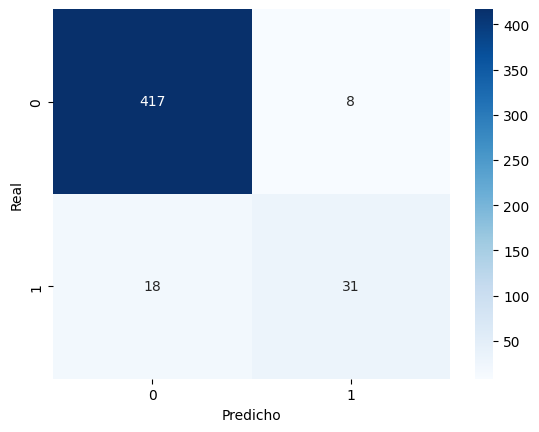

In [44]:
# MATRIZ DE CONFUSIÓN FINAL
cm_final = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

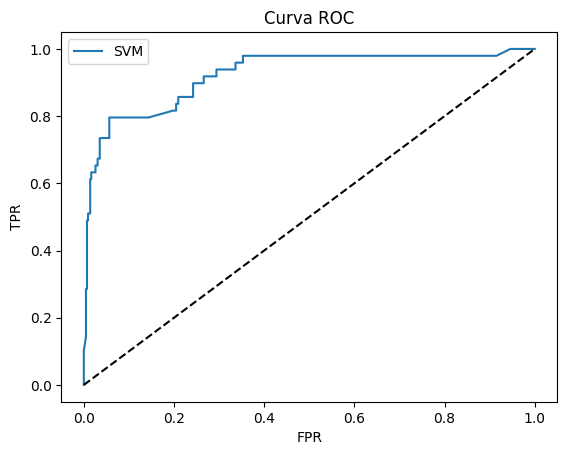

In [45]:
# CURVA ROC
y_prob = pipeline_final.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='SVM')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.show()

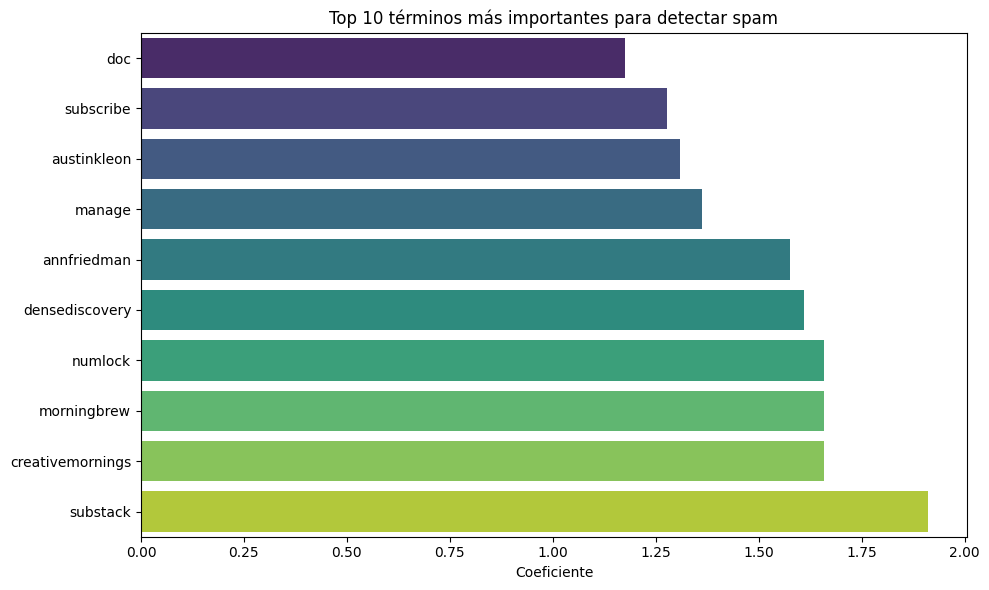

In [46]:
# IMPORTANCIA DE FEATURES

tfidf = pipeline_final.named_steps['tfidf']
svm = pipeline_final.named_steps['svm']

# Obtenemos nombres de features
feature_names = np.array(tfidf.get_feature_names_out())

# Coeficientes del SVM (convertimos a dense para evitar errores)
coef = svm.coef_.toarray()[0]  # toarray() convierte sparse a numpy array

# Top 10 términos más importantes para spam (coeficientes positivos más altos)
top_indices = np.argsort(coef)[-10:]

plt.figure(figsize=(10, 6))
sns.barplot(x=coef[top_indices], y=feature_names[top_indices], palette="viridis")
plt.title("Top 10 términos más importantes para detectar spam")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

In [50]:
# GUARDAR EL MODELO
joblib.dump(pipeline_final, 'modelo_svm_spam_final.pkl')

['modelo_svm_spam_final.pkl']

# Conclusiones
Hemos creado un detector de URLs spam usando solo el texto de la URL.

Dataset final: 2.369 URLs (10 % spam).
Preprocesamiento: tokenización por delimitadores + lematización.
Modelo base (SVM lineal): accuracy 94 %, recall spam 0.45.
Modelo final (SVM RBF optimizado):
→ accuracy 96 %
→ recall spam 0.71 (+56 %)
→ AUC 0.92

Obtenemos un modelo que puede usarse directamente en navegadores o filtros de correo. Con solo TF-IDF + SVM se consigue un rendimiento excelente usando únicamente la propia URL.